In [70]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Data Science/Data/annual_summary_austin.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,year,mean_temp_max_f
0,1940,74.860164
1,1941,73.588384
2,1942,74.747781
3,1943,77.564658
4,1944,77.513934


In [13]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Data Science/Data/annual_summary_austin.csv')
df.head()
df.columns

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Index(['Metric', 'Value'], dtype='object')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


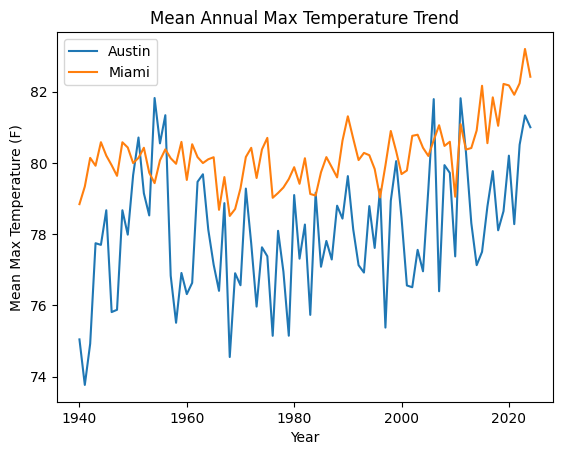

1000

In [82]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

# This `df` currently holds summary data. Let's rename it to avoid confusion.
austin_summary_df = pd.read_csv('/content/drive/MyDrive/Data Science/Data/annual_summary_austin.csv')
austin_summary_df.head()
austin_summary_df.columns
len(austin_summary_df)


import requests
# Removed the redundant manual API call for Miami and the global `annual_df` as `fetch_and_clean` will handle it.

def fetch_and_clean(lat, lon):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {"latitude": lat, "longitude": lon, "start_date": "1940-01-01", "end_date": "2024-12-31", "daily": "temperature_2m_max", "temperature_unit": "fahrenheit", "timezone": "auto"}
    response = requests.get(url, params=params)
    data = response.json()
    if "daily" in data:
        daily_df = pd.DataFrame(data["daily"])
        daily_df["time"] = pd.to_datetime(daily_df["time"])
        daily_df["year"] = daily_df["time"].dt.year
        annual_df = daily_df.groupby("year")["temperature_2m_max"].mean()
        annual_df = annual_df.reset_index()
        annual_df = annual_df.rename(columns={"temperature_2m_max": "mean_temp_max_f"})
        return annual_df
    else:
        print(f"API Error in fetch_and_clean for coordinates ({lat}, {lon}): {data.get('reason', 'Unknown error')}")
        # FIX: Return an empty DataFrame with the expected columns to prevent KeyError in plotting
        return pd.DataFrame(columns=['year', 'mean_temp_max_f'])

# Fetch Austin data (assuming Austin coordinates: 30.2672, -97.7431)
austin_temp_df = fetch_and_clean(30.2672, -97.7431)

# Fetch Miami data
miami_df = fetch_and_clean(25.7617, -80.1918)
# Removed the incorrect line: miami_df = annual_df
# Only attempt to save if the DataFrame is not empty
if not miami_df.empty:
    miami_df.to_csv("annual_summary_miami.csv")



import matplotlib.pyplot as plt
fig, ax = plt.subplots()

df = austin_temp_df
ax.plot(df["year"], df["mean_temp_max_f"], label="Austin")
ax.plot(miami_df["year"], miami_df["mean_temp_max_f"], label="Miami")
ax.set_xlabel("Year")
ax.set_ylabel("Mean Max Temperature (F)")
ax.set_title("Mean Annual Max Temperature Trend")
ax.legend()
plt.show()

np.float64(0.5621852928539164)

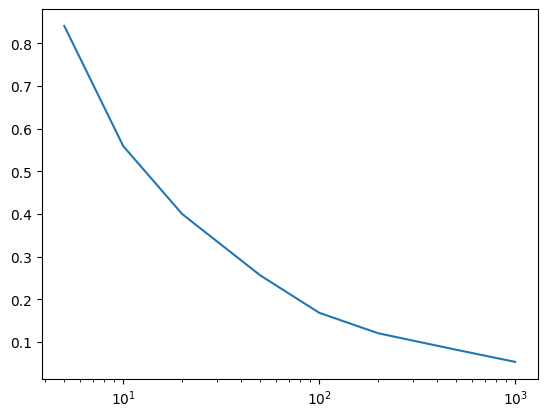

In [111]:
import numpy as np

temps = austin_temp_df["mean_temp_max_f"].values
sample_size = 10
n_simulations = 1000
simulated_means = []
for i in range(n_simulations):
  sample = np.random.choice(temps, size=sample_size, replace=True)
  simulated_means.append(sample.mean())
len(simulated_means)
simulated_means[:5]
np.std(simulated_means)
[np.random.choice(temps, size=sample_size, replace=True).mean() for _ in range(n_simulations)]
simulated_means = [np.random.choice(temps, size=sample_size, replace=True).mean() for _ in range(n_simulations)]

sample_sizes = [5, 10, 20, 50, 100, 200, 500, 1000]
se_values = []
for n in sample_sizes:
  simulated_means = [np.random.choice(temps, size=n, replace=True).mean() for _ in range(n_simulations)]
  se_values.append(np.std(simulated_means))
len(se_values)
fig, ax = plt.subplots()
ax.plot(sample_sizes, se_values)
plt.xscale("log")
np.std(temps)
1.777785992467158 / np.sqrt(10)

- the comparison city: Miami, Florida, USA
- I chose Miami Florida to compare against because it is in the US and would prove if the world is really heating up.
- If I do find a trend similar to warming that would mean that the world is heating up.

- comparison city: Miami
- years of data available: 85

- Austin and Miami both show increasing temperatures
- this strengthens the case for a broader pattern beyond Austin alone
- but it does not rule out alternatives like urbanization, land-use change, or measurement issues
- comparing with rural stations or independent datasets would help test those alternatives

- SE for n = 10 ≈ 0.56 °F
- A 10 year sample gives a omewhat variable estimate of Austin's true mean annual max temperature

- the SE-vs-sample-size curve slopes downward, drops quickly at first, then flattens
- larger samples give lower SE
- the simulated SE for n = 10 was close to the formula result, so the two methods agree

- Miami was chosen as a broader cross-climate comparison within one country
- both cities showed increasing temperatures, which suggests Austin's warming is not unique to Austin alone
- but two cities do not prove a global pattern or identify a single cause